In [4]:
import os
import pandas as pd
from collections import defaultdict

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')

# 기준 오브젝트
english_objects = {"Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"}
number_objects = {"0", "10", "30", "50", "100"}

# 세션 분류 함수
def classify_object_type(session_df):
    object_names = set(session_df["object_name"].astype(str))
    if object_names.issubset(english_objects):
        return "재질 O"
    elif object_names.issubset(number_objects):
        return "재질 X"
    else:
        return "혼합"

# 전체 누적 결과 저장용 리스트
all_sessions = []

def plot_total_grab(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # 전처리
            df = df.dropna(subset=["session", "object_name", "total_grab", "correct"])
            df["object_name"] = df["object_name"].astype(str)
            df["session"] = df["session"].astype(int)
            df["total_grab"] = df["total_grab"].astype(float)
            df["correct"] = df["correct"].astype(bool)

            session_info = []
            for session_id, session_df in df.groupby("session"):
                obj_type = classify_object_type(session_df)
                last_total_grab = session_df["total_grab"].iloc[-1]
                accuracy = session_df["correct"].mean() * 100
                duration = session_df["session_duration"].iloc[-1]
                session_info.append({
                    "session": session_id,
                    "object_type": obj_type,
                    "total_grab": last_total_grab,
                    "accuracy": accuracy,
                    "session_duration": duration,
                    "source_file": file
                })

            result_df = pd.DataFrame(session_info)
            all_sessions.append(result_df)  # ✅ 누적

            # 파일별 출력
            eng_df = result_df[result_df["object_type"] == "재질 O"]
            num_df = result_df[result_df["object_type"] == "재질 X"]

            print(f"\n📄 파일: {file}")
            print(f"🧠 재질 O 평균 total_grab: {eng_df['total_grab'].mean():.2f}" if not eng_df.empty else "❌ 재질 O 세션 없음")
            print(f"🔢 재질 X 평균 total_grab: {num_df['total_grab'].mean():.2f}" if not num_df.empty else "❌ 재질 X 세션 없음")

            print("🎯 평균 정확도 (%):")
            print(f"   🧠 재질 O: {eng_df['accuracy'].mean():.2f}%" if not eng_df.empty else "   ❌ 재질 O 세션 없음")
            print(f"   🔢 재질 X: {num_df['accuracy'].mean():.2f}%" if not num_df.empty else "   ❌ 재질 X 세션 없음")

            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

            # print(eng_df.columns)
    
            # total_grab plot
            for df_type, label, color in zip([eng_df, num_df], ["재질 O", "재질 X"], ["blue", "green"]):
                if not df_type.empty:
                    ax1.plot(df_type["session"], df_type["total_grab"], marker='o', label=label, color=color)
            ax1.set_title(f"{file} - 세션별 Total Grab")
            ax1.set_ylabel("Total Grab")
            ax1.legend()
            ax1.grid(True)

            # session_duration plot
            for df_type, label, color in zip([eng_df, num_df], ["재질 O", "재질 X"], ["blue", "green"]):
                if not df_type.empty and "session_duration" in df_type.columns:
                    ax2.plot(df_type["session"], df_type["session_duration"], marker='s', linestyle='--', label=label, color=color)
            ax2.set_title("세션별 Duration (초)")
            ax2.set_xlabel("Session")
            ax2.set_ylabel("Duration (s)")
            ax2.legend()
            ax2.grid(True)

            plt.tight_layout()
            plt.show()


    # ✅ 전체 세션 결과 통합 후 계산
    full_df = pd.concat(all_sessions, ignore_index=True)

    eng_all = full_df[full_df["object_type"] == "재질 O"]
    num_all = full_df[full_df["object_type"] == "재질 X"]

        # 📊 전체 Grab 및 Duration 합계 출력
    print("\n📦 전체 파일 기준 Grab 합계 및 Duration:")

    total_grab_eng = eng_all["total_grab"].sum()
    total_grab_num = num_all["total_grab"].sum()

    duration_eng = eng_all["session_duration"].sum()
    duration_num = num_all["session_duration"].sum()

    print(f"   🧠 재질 O 전체 Grab 합계: {total_grab_eng:.0f}")
    print(f"   🔢 재질 X 전체 Grab 합계: {total_grab_num:.0f}")

    print(f"   🧠 재질 O 전체 Duration (s): {duration_eng:.2f}초")
    print(f"   🔢 재질 X 전체 Duration (s): {duration_num:.2f}초")

    # (옵션) 평균도 같이 보고 싶다면 아래도 추가
    print(f"\n📊 평균 기준:")
    print(f"   🧠 재질 O 평균 Duration: {eng_all['session_duration'].mean():.2f}초")
    print(f"   🔢 재질 X 평균 Duration: {num_all['session_duration'].mean():.2f}초")

    print(f"   🧠 재질 O 평균 Grab 횟수: {eng_all['total_grab'].mean():.2f}")
    print(f"   🔢 재질 X 평균 Grab 횟수: {num_all['total_grab'].mean():.2f}")
    
    # ✅ 재질별 평균 정확도 출력
    print(f"\n🎯 재질별 평균 정확도:")
    print(f"   🧠 재질 O 평균 정확도: {eng_all['accuracy'].mean():.2f}%")
    print(f"   🔢 재질 X 평균 정확도: {num_all['accuracy'].mean():.2f}%")


📄 파일: Merge_dohoon_full.csv
🧠 재질 O 평균 total_grab: 8.60
🔢 재질 X 평균 total_grab: 9.60
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 100.00%


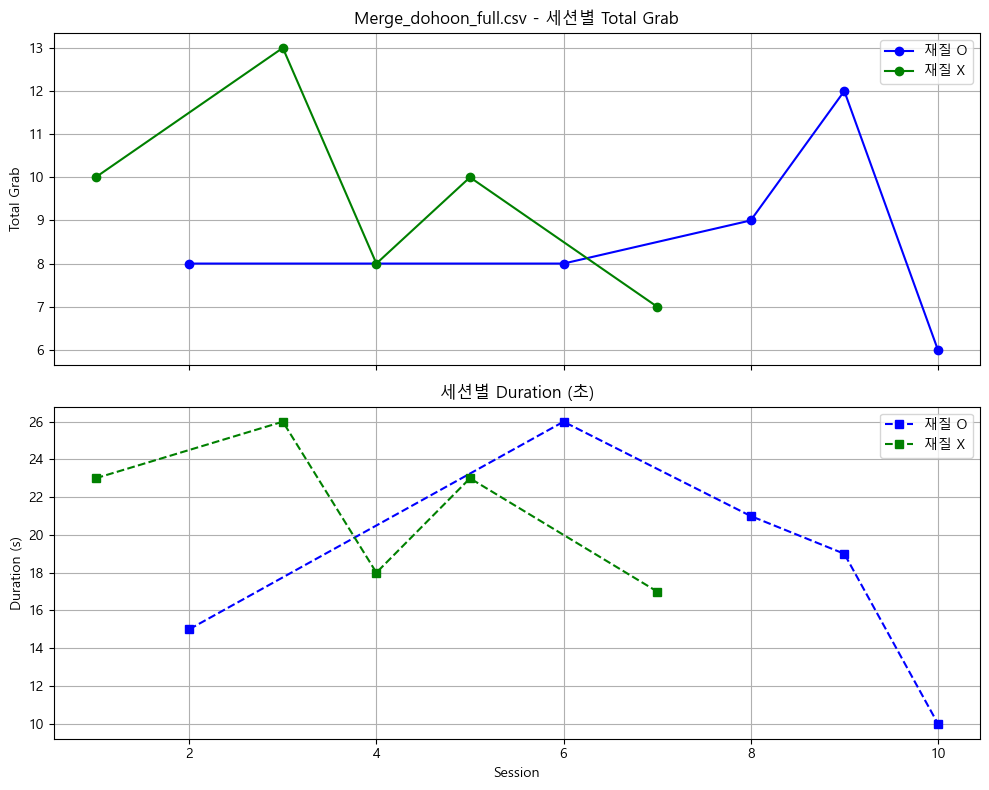


📄 파일: Merge_jaeho_full.csv
🧠 재질 O 평균 total_grab: 20.60
🔢 재질 X 평균 total_grab: 14.80
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 92.00%


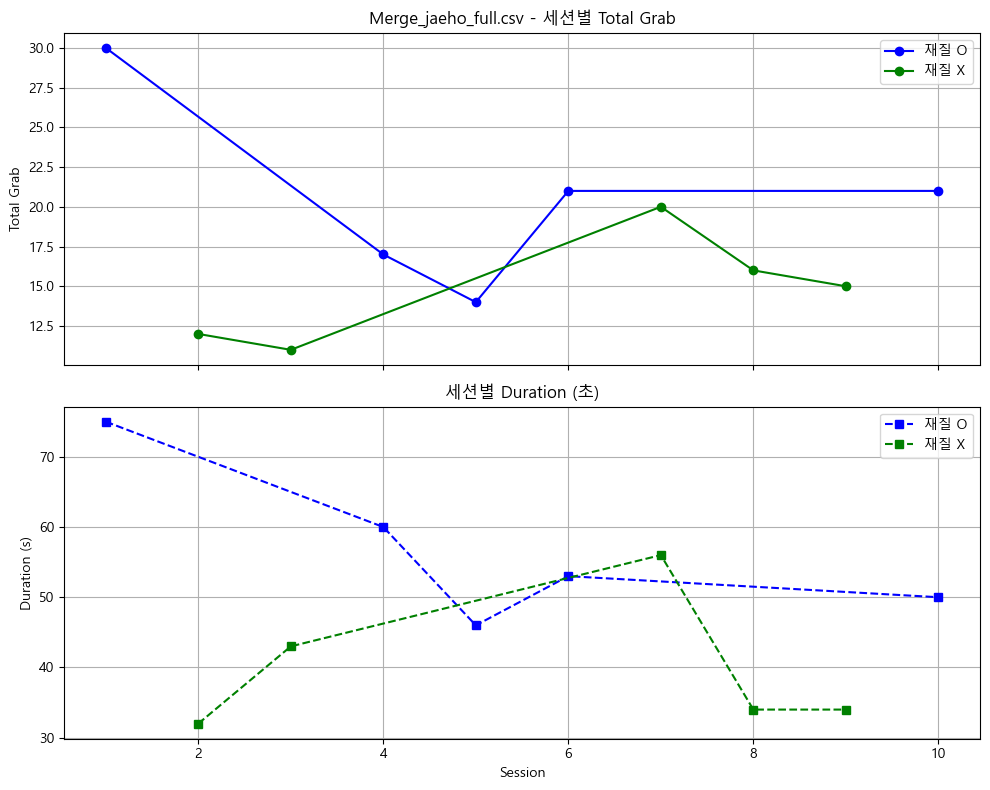


📄 파일: Merge_minho_full.csv
🧠 재질 O 평균 total_grab: 8.80
🔢 재질 X 평균 total_grab: 12.80
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 92.00%


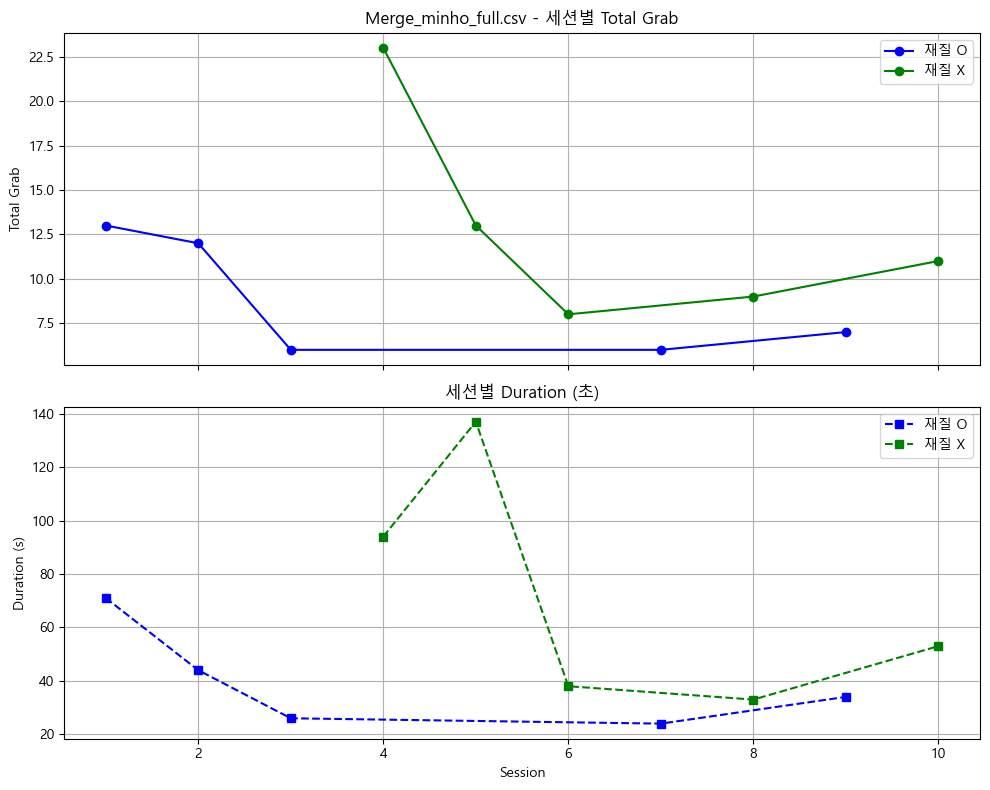


📄 파일: Merge_uiseong_full.csv
🧠 재질 O 평균 total_grab: 10.60
🔢 재질 X 평균 total_grab: 11.60
🎯 평균 정확도 (%):
   🧠 재질 O: 100.00%
   🔢 재질 X: 100.00%


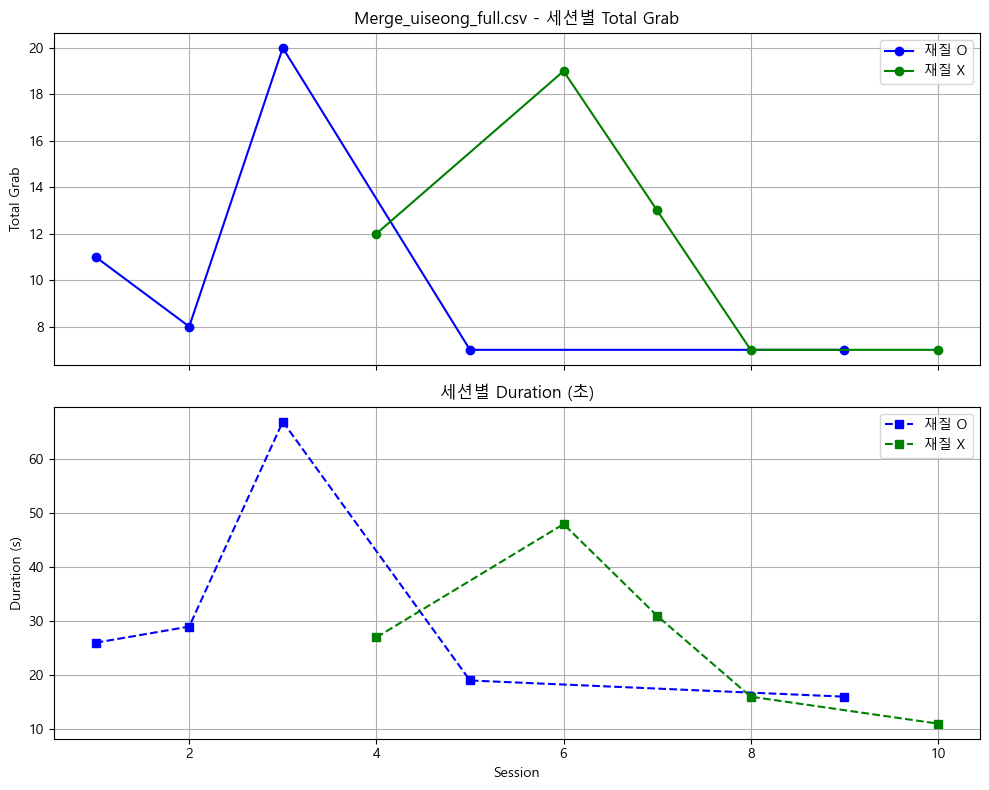


📄 파일: Merge_ys_full.csv
🧠 재질 O 평균 total_grab: 21.00
🔢 재질 X 평균 total_grab: 21.60
🎯 평균 정확도 (%):
   🧠 재질 O: 76.00%
   🔢 재질 X: 52.00%


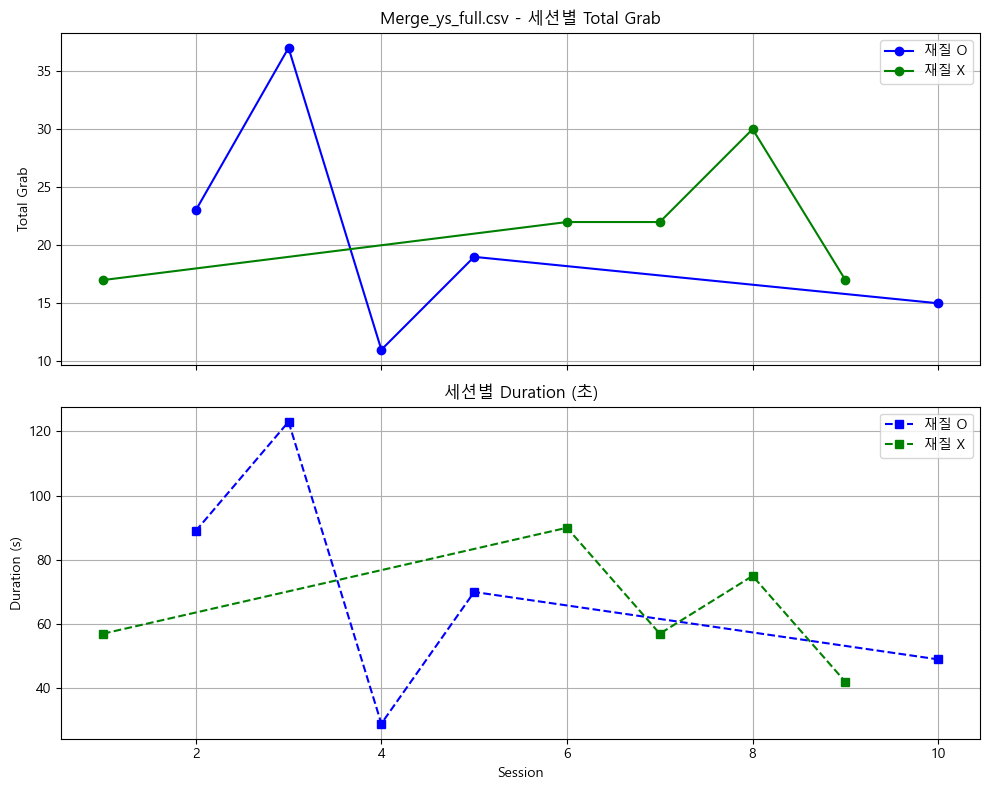


📦 전체 파일 기준 Grab 합계 및 Duration:
   🧠 재질 O 전체 Grab 합계: 348
   🔢 재질 X 전체 Grab 합계: 352
   🧠 재질 O 전체 Duration (s): 1091.00초
   🔢 재질 X 전체 Duration (s): 1115.00초

📊 평균 기준:
   🧠 재질 O 평균 Duration: 43.64초
   🔢 재질 X 평균 Duration: 44.60초
   🧠 재질 O 평균 Grab 횟수: 13.92
   🔢 재질 X 평균 Grab 횟수: 14.08

🎯 재질별 평균 정확도:
   🧠 재질 O 평균 정확도: 95.20%
   🔢 재질 X 평균 정확도: 87.20%


In [8]:
plot_total_grab("./Full_o")

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def print_detailed_accuracy_with_confusion(folder_path):
    all_df_list = []  # ✅ 전체 누적용

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            # 전처리
            df = df.dropna(subset=["correct", "session", "object_name", "expected_zone", "zone"])
            df["correct"] = df["correct"].astype(bool)
            df["object_name"] = df["object_name"].astype(str)
            df["session"] = df["session"].astype(int)
            df["zone"] = df["zone"].astype(int)
            df["expected_zone"] = df["expected_zone"].astype(int)

            all_df_list.append(df)  # ✅ 누적

            # 세션별 정확도 출력
            results = []
            for session_id, session_df in df.groupby("session"):
                accuracy = session_df["correct"].mean() * 100
                object_type = classify_object_type(session_df)
                total_grab = session_df["total_grab"].dropna().iloc[-1] if not session_df["total_grab"].dropna().empty else None

                results.append({
                    "session": session_id,
                    "accuracy (%)": round(accuracy, 2),
                    "object_type": object_type,
                    "total_grab": int(total_grab) if pd.notnull(total_grab) else "N/A"
                })

            print(f"\n📄 파일: {file}")
            print(pd.DataFrame(results).to_string(index=False))
            print(f"📊 전체 정확도: {df['correct'].mean() * 100:.2f}%")

            # 혼동 행렬 출력 및 시각화
            labels = sorted(df["expected_zone"].unique())
            cm = confusion_matrix(df["expected_zone"], df["zone"], labels=labels)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            disp.plot(cmap="Blues")
            plt.title(f"{file} - 혼동 행렬")
            plt.tight_layout()
            plt.show()

    # ✅ 전체 데이터 누적 후 전체 혼동 행렬 시각화
    if all_df_list:
        full_df = pd.concat(all_df_list, ignore_index=True)
        print("\n📦 전체 파일 기준 혼동 행렬:")

        labels = sorted(full_df["expected_zone"].unique())
        cm_all = confusion_matrix(full_df["expected_zone"], full_df["zone"], labels=labels)

        cm_df_all = pd.DataFrame(cm_all, index=[f"GT_{i}" for i in labels], columns=[f"P_{i}" for i in labels])
        print(cm_df_all)

        disp_all = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=labels)
        disp_all.plot(cmap="Oranges")
        plt.title("전체 파일 기준 혼동 행렬")
        plt.tight_layout()
        plt.show()



📄 파일: Merge_dohoon_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 X          10
       2         100.0        재질 O           8
       3         100.0        재질 X          13
       4         100.0        재질 X           8
       5         100.0        재질 X          10
       6         100.0        재질 O           8
       7         100.0        재질 X           7
       8         100.0        재질 O           9
       9         100.0        재질 O          12
      10         100.0        재질 O           6
📊 전체 정확도: 100.00%


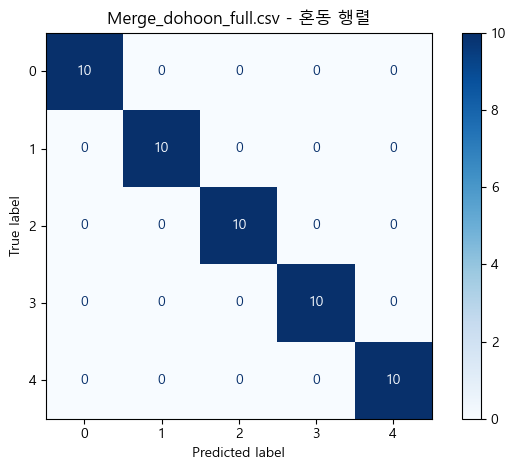


📄 파일: Merge_jaeho_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          30
       2          60.0        재질 X          12
       3         100.0        재질 X          11
       4         100.0        재질 O          17
       5         100.0        재질 O          14
       6         100.0        재질 O          21
       7         100.0        재질 X          20
       8         100.0        재질 X          16
       9         100.0        재질 X          15
      10         100.0        재질 O          21
📊 전체 정확도: 96.00%


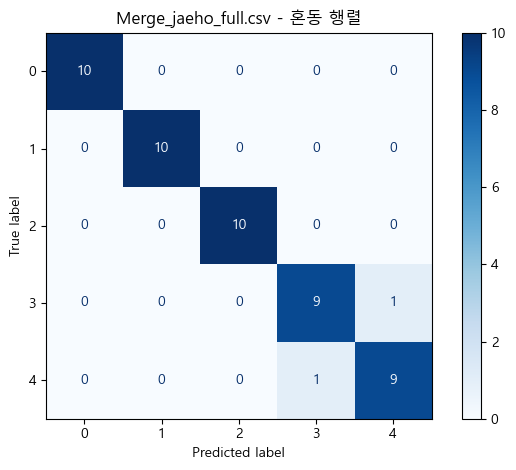


📄 파일: Merge_minho_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          13
       2         100.0        재질 O          12
       3         100.0        재질 O           6
       4          60.0        재질 X          23
       5         100.0        재질 X          13
       6         100.0        재질 X           8
       7         100.0        재질 O           6
       8         100.0        재질 X           9
       9         100.0        재질 O           7
      10         100.0        재질 X          11
📊 전체 정확도: 96.00%


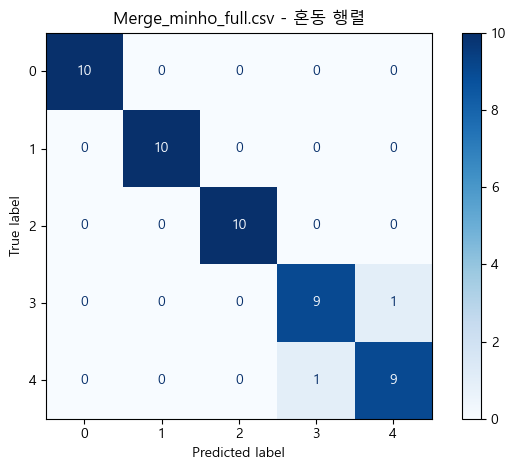


📄 파일: Merge_uiseong_full.csv
 session  accuracy (%) object_type  total_grab
       1         100.0        재질 O          11
       2         100.0        재질 O           8
       3         100.0        재질 O          20
       4         100.0        재질 X          12
       5         100.0        재질 O           7
       6         100.0        재질 X          19
       7         100.0        재질 X          13
       8         100.0        재질 X           7
       9         100.0        재질 O           7
      10         100.0        재질 X           7
📊 전체 정확도: 100.00%


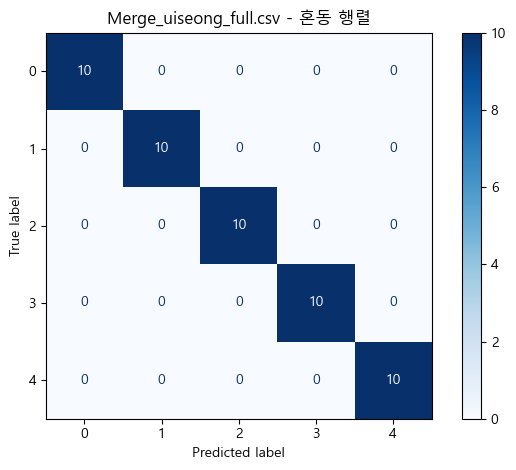


📄 파일: Merge_ys_full.csv
 session  accuracy (%) object_type  total_grab
       1          60.0        재질 X          17
       2          60.0        재질 O          23
       3         100.0        재질 O          37
       4          60.0        재질 O          11
       5          60.0        재질 O          19
       6          60.0        재질 X          22
       7          60.0        재질 X          22
       8          20.0        재질 X          30
       9          60.0        재질 X          17
      10         100.0        재질 O          15
📊 전체 정확도: 64.00%


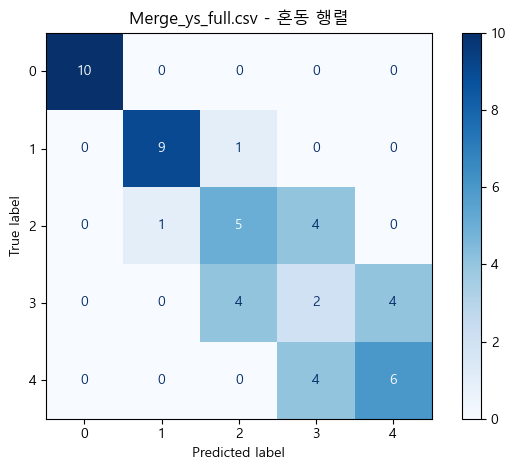


📦 전체 파일 기준 혼동 행렬:
      P_0  P_1  P_2  P_3  P_4
GT_0   50    0    0    0    0
GT_1    0   49    1    0    0
GT_2    0    1   45    4    0
GT_3    0    0    4   40    6
GT_4    0    0    0    6   44


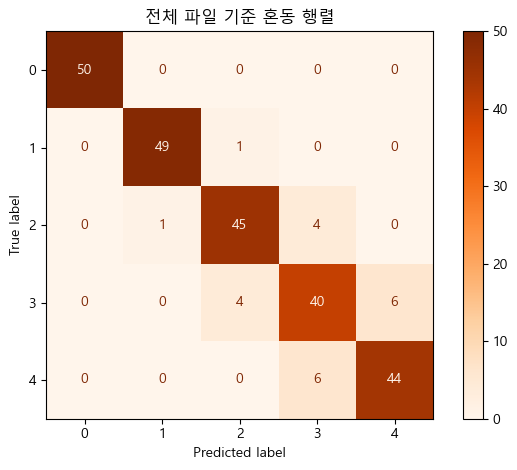

In [11]:
print_detailed_accuracy_with_confusion("./Full_o")

In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

def summarize_object_grab_by_type_with_plot(folder_path):
    english_objects = ["Fur ball", "Sponge ball", "bouncy ball", "BaseBall", "Steal ball"]
    number_objects = ["0", "10", "30", "50", "100"]

    all_data = []

    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            try:
                df = pd.read_csv(file_path)
                df["object_name"] = df["object_name"].astype(str)
                df["object_grab"] = pd.to_numeric(df["object_grab"], errors="coerce")

                def classify(obj):
                    if obj in english_objects:
                        return "재질 O"
                    elif obj in number_objects:
                        return "재질 X"
                    else:
                        return "기타"

                df["material_type"] = df["object_name"].apply(classify)
                all_data.append(df)

                print(f"\n📄 파일: {file}")

                for label, emoji in [("재질 O", "🧠"), ("재질 X", "🔢")]:
                    sub_df = df[df["material_type"] == label]
                    total_grab_sum = sub_df["object_grab"].sum()
                    print(f"{emoji} {label} 합계: {int(total_grab_sum)}")
                    grouped = sub_df.groupby("object_name")["object_grab"].sum()
                    for obj, grab_sum in grouped.items():
                        print(f" - {obj}: grab {int(grab_sum)}")

            except Exception as e:
                print(f"⚠️ 오류 발생: {file} → {e}")

    if all_data:
        total_df = pd.concat(all_data, ignore_index=True)

        # 📊 재질별 데이터
        eng_df = total_df[total_df["material_type"] == "재질 O"]
        num_df = total_df[total_df["material_type"] == "재질 X"]

        eng_grab = eng_df.groupby("object_name")["object_grab"].sum().reindex(english_objects).fillna(0)
        num_grab = num_df.groupby("object_name")["object_grab"].sum().reindex(number_objects).fillna(0)

        # === 개별 그래프: 재질 O
        plt.figure(figsize=(8, 4))
        eng_grab.plot(kind="bar", color="skyblue")
        plt.title("🧠 재질 O 오브젝트별 Grab 합계")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 합계")
        plt.ylim(0, 300)
        plt.yticks(np.arange(0, 301, 25))
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # === 개별 그래프: 재질 X
        plt.figure(figsize=(8, 4))
        num_grab.plot(kind="bar", color="lightcoral")
        plt.title("🔢 재질 X 오브젝트별 Grab 합계")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 합계")
        plt.ylim(0, 300)
        plt.yticks(np.arange(0, 301, 25))
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # === 선 그래프: 재질 O & X 비교
        plt.figure(figsize=(10, 5))
        plt.plot(english_objects, eng_grab.values, marker='o', label="재질 O", color="blue")
        plt.plot(number_objects, num_grab.values, marker='s', label="재질 X", color="red")
        plt.title("재질 O vs 재질 X 오브젝트별 Grab 합계 비교 (선그래프)")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 합계")
        plt.ylim(0, 300)
        plt.yticks(np.arange(0, 301, 25))
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        
                # === 평균값 그래프: 재질 O
        eng_mean = eng_df.groupby("object_name")["object_grab"].mean().reindex(english_objects).fillna(0)

        plt.figure(figsize=(8, 4))
        eng_mean.plot(kind="bar", color="deepskyblue")
        plt.title("🧠 재질 O 오브젝트별 Grab 평균")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 5)
        plt.yticks(np.arange(0, 6, 1))
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # === 평균값 그래프: 재질 X
        num_mean = num_df.groupby("object_name")["object_grab"].mean().reindex(number_objects).fillna(0)

        plt.figure(figsize=(8, 4))
        num_mean.plot(kind="bar", color="salmon")
        plt.title("🔢 재질 X 오브젝트별 Grab 평균")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 5)
        plt.yticks(np.arange(0, 6, 1))
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # === 평균 선 그래프 비교
        plt.figure(figsize=(10, 5))
        plt.plot(english_objects, eng_mean.values, marker='o', label="재질 O 평균", color="blue", linestyle='-')
        plt.plot(number_objects, num_mean.values, marker='s', label="재질 X 평균", color="red", linestyle='--')
        plt.title("재질 O vs 재질 X 오브젝트별 Grab 평균 비교 (선그래프)")
        plt.xlabel("Object Name")
        plt.ylabel("Grab 평균")
        plt.ylim(0, 10)
        plt.yticks(np.arange(0, 11, 1))
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()



📄 파일: Merge_dohoon_full.csv
🧠 재질 O 합계: 43
 - BaseBall: grab 10
 - Fur ball: grab 6
 - Sponge ball: grab 12
 - Steal ball: grab 8
 - bouncy ball: grab 7
🔢 재질 X 합계: 48
 - 0: grab 5
 - 10: grab 10
 - 100: grab 13
 - 30: grab 5
 - 50: grab 15

📄 파일: Merge_jaeho_full.csv
🧠 재질 O 합계: 103
 - BaseBall: grab 29
 - Fur ball: grab 9
 - Sponge ball: grab 12
 - Steal ball: grab 19
 - bouncy ball: grab 34
🔢 재질 X 합계: 74
 - 0: grab 9
 - 10: grab 12
 - 100: grab 20
 - 30: grab 15
 - 50: grab 18

📄 파일: Merge_minho_full.csv
🧠 재질 O 합계: 44
 - BaseBall: grab 8
 - Fur ball: grab 7
 - Sponge ball: grab 11
 - Steal ball: grab 10
 - bouncy ball: grab 8
🔢 재질 X 합계: 64
 - 0: grab 10
 - 10: grab 10
 - 100: grab 14
 - 30: grab 11
 - 50: grab 19

📄 파일: Merge_uiseong_full.csv
🧠 재질 O 합계: 53
 - BaseBall: grab 11
 - Fur ball: grab 5
 - Sponge ball: grab 7
 - Steal ball: grab 17
 - bouncy ball: grab 13
🔢 재질 X 합계: 58
 - 0: grab 5
 - 10: grab 13
 - 100: grab 14
 - 30: grab 14
 - 50: grab 12

📄 파일: Merge_ys_full.csv
🧠 재질 O 합

c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\ipykernel_launcher.py:63: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


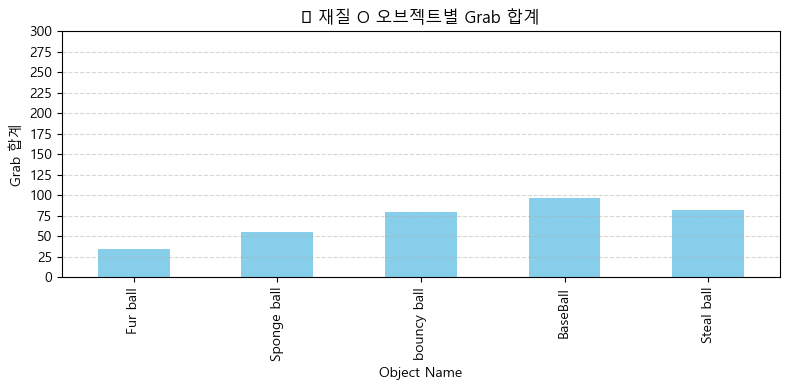

c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\ipykernel_launcher.py:75: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from current font.
c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


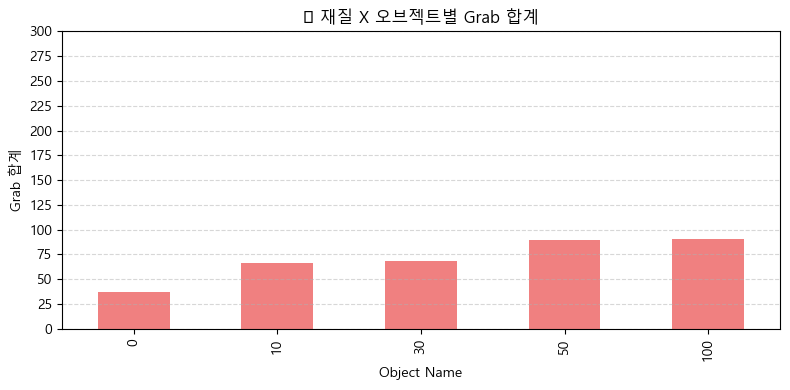

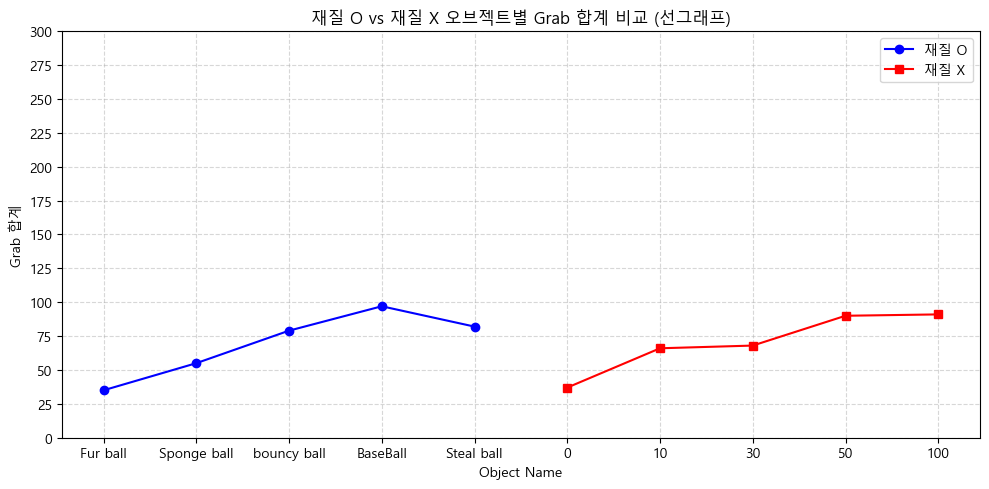

c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\ipykernel_launcher.py:103: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


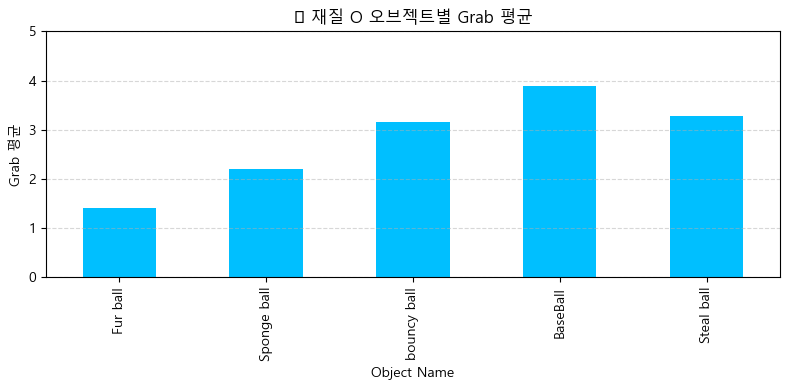

c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\ipykernel_launcher.py:117: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from current font.
c:\Users\ehfkw\anaconda3\envs\kocca\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


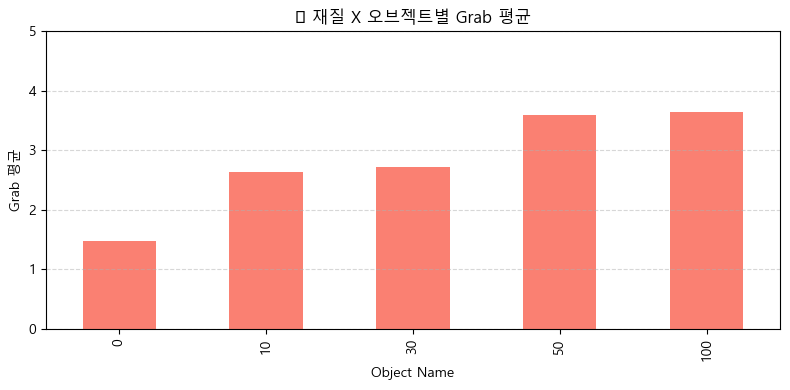

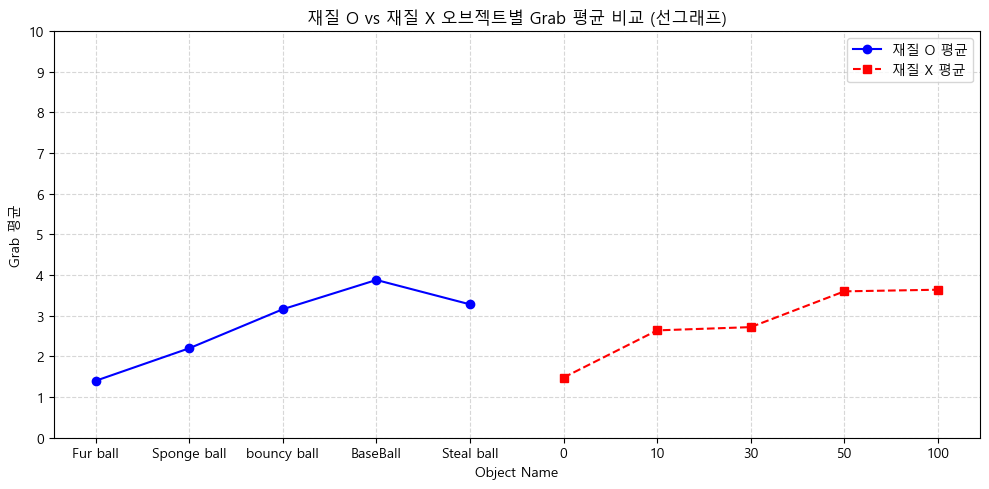

In [15]:
summarize_object_grab_by_type_with_plot("./Full_o")